# Retail Sales & Discount Analysis
Dataset: Superstore Sales dataset CSV (Kaggle) 

This project analyzes retail sales data to identify key drivers of profitability, with a focus on discount strategy, product performance, and customer segmentation. The analysis was conducted using Python (Pandas, Matplotlib) for data exploration, aggregation, and visualization. 

All analysis, data processing, and visualization were conducted independently.

## Business Questions

1. Which product categories generate the most revenue and profit?
2. How do discounts impact profitability?
3. How are sales according to different regions?
4. Which customer segments contribute most to sales and profit?
5. How does shipping mode relate to performance?

## Import Libraries & Upload Dataset

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# Upload dataset
df = pd.read_csv("SampleSuperstore.csv")

## Exploratory Data Analysis

In [31]:
# Show columns
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [24]:
# Show first 5 rows
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [25]:
# Number of rows and columns 
df.shape #(rows, columns)

(9994, 13)

In [26]:
# Data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [27]:
# Missing values count
df.isnull().sum()                                    #no missing values in this datasest

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [128]:
# Count of 0 (missing values encoded as 0 sometimes)
(df == 0).sum()                                      #missing values encoded as 0 in 'Discount' and 'Profit' columns

Ship Mode             0
Segment               0
Country               0
City                  0
State                 0
Postal Code           0
Region                0
Category              0
Sub-Category          0
Sales                 0
Quantity              0
Discount           4798
Profit               65
Profit_per_unit      65
dtype: int64

array([[<Axes: title={'center': 'Postal Code'}>,
        <Axes: title={'center': 'Sales'}>],
       [<Axes: title={'center': 'Quantity'}>,
        <Axes: title={'center': 'Discount'}>],
       [<Axes: title={'center': 'Profit'}>, <Axes: >]], dtype=object)

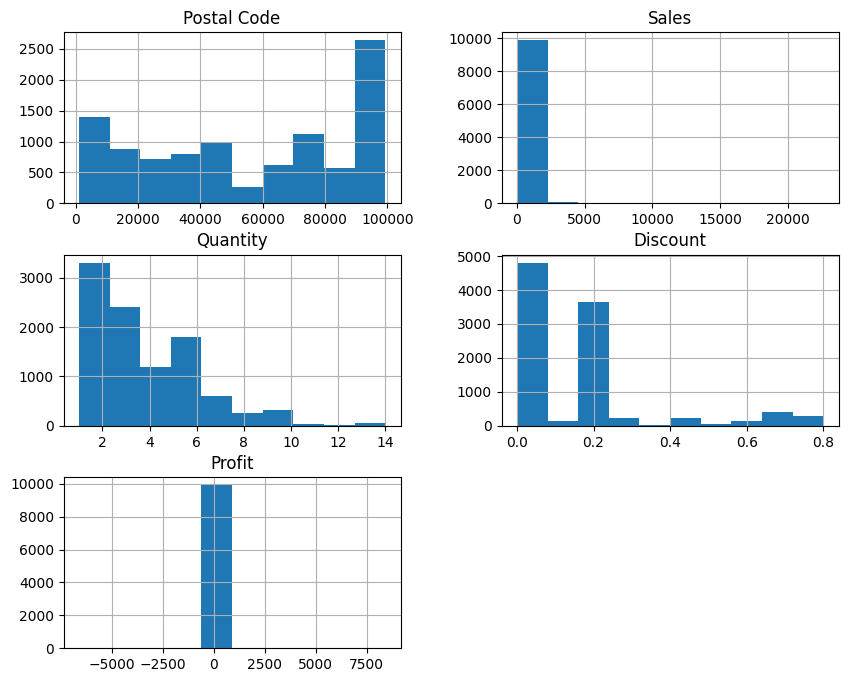

In [16]:
# Histograms of numerical columns
df.hist(figsize=(10,8))

In [14]:
# Descriptive statistics (count, mean, std, percentiles, min and max values)
#print(df.describe(exclude=[object]))                                        #to exclude specific data type
#df.describe(include='all')                                                  #for all columns

df.describe()                                                                #for numerical columns

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Business Question # 1: Which products or categories generate the most revenue?

In [116]:
# Sales by 'Category' column in descending order
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)        #Technology generates most sales 

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

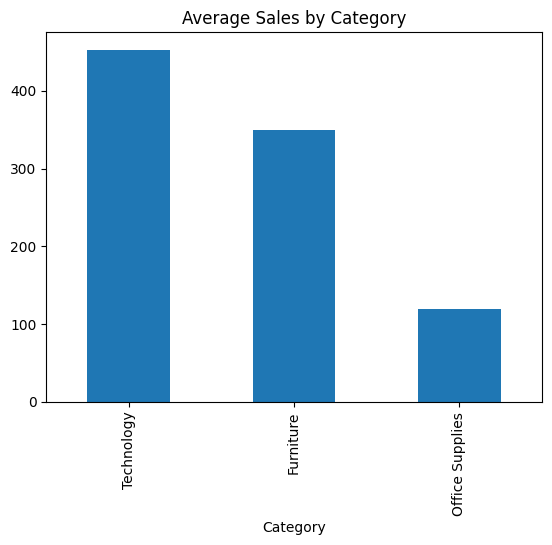

In [163]:
# Visualize sales by Category 
df.groupby("Category")["Sales"].mean().sort_values(ascending=False).plot(kind="bar")          #Technology generates highest slaes
plt.title("Average Sales by Category")
plt.show()

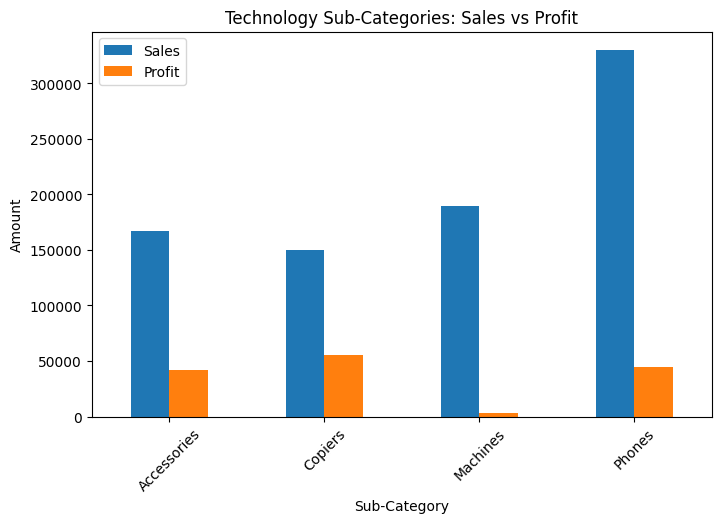

In [155]:
# Visualize sales by Category 
tech = df[df["Category"] == "Technology"]

tech_grouped = tech.groupby("Sub-Category")[["Sales", "Profit"]].sum()                             #Phones generate highest profit within Technology

tech_grouped.plot(kind="bar", figsize=(8,5))
plt.title("Technology Sub-Categories: Sales vs Profit")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

## Business Question 2: Do discounts actually reduce profit?

In [124]:
# Discount percentage with corresponding mean profit                         #0-10% discount leads to highest profit
df.groupby("Discount")["Profit"].mean()                                      #controlled discounting can increase sales without harming profit
                                                                             #above 20% discount, profits start collapsing
                                                                             #above 50% discount, consistently negative 

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

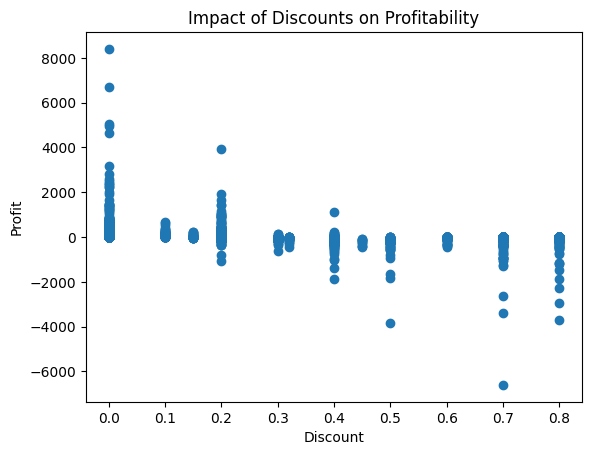

In [8]:
# Visualize Discount vs. Profit
plt.scatter(df["Discount"], df["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Impact of Discounts on Profitability")
plt.show()

In [131]:
df.groupby("Category")[["Discount", "Sales", "Profit"]].sum()                  #Furniture is way behind in profit (18K), Technology highest (145K)

,Discount,Sales,Profit
Category,,,
Furniture,368.89,741999.7953,18451.2728
Office Supplies,947.80,719047.0320,122490.8008
Technology,244.40,836154.0330,145454.9481


In [132]:
df.groupby("Category")["Profit"].mean()                                        #Average profit per order 

Category
Furniture           8.699327
Office Supplies    20.327050
Technology         78.752002
Name: Profit, dtype: float64

In [134]:
df[df["Category"] == "Furniture"].groupby("Sub-Category")["Profit"].mean()     #Tables and bookcases drive the highest losses in Furniture

Sub-Category
Bookcases     -15.230509
Chairs         43.095894
Furnishings    13.645918
Tables        -55.565771
Name: Profit, dtype: float64

Furniture has the highest discount levels but generates the lowest profit per order by a large margin. 
Losses in the Furniture category are driven primarily by Tables and Bookcases, which show negative average profit despite overall category revenue.

## Business Q3: How are sales according to different regions?

In [57]:
# Group Sales and Profit by Region
df.groupby("Region")[["Sales", "Profit"]].sum()                                    #West produces highest sales + profit

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


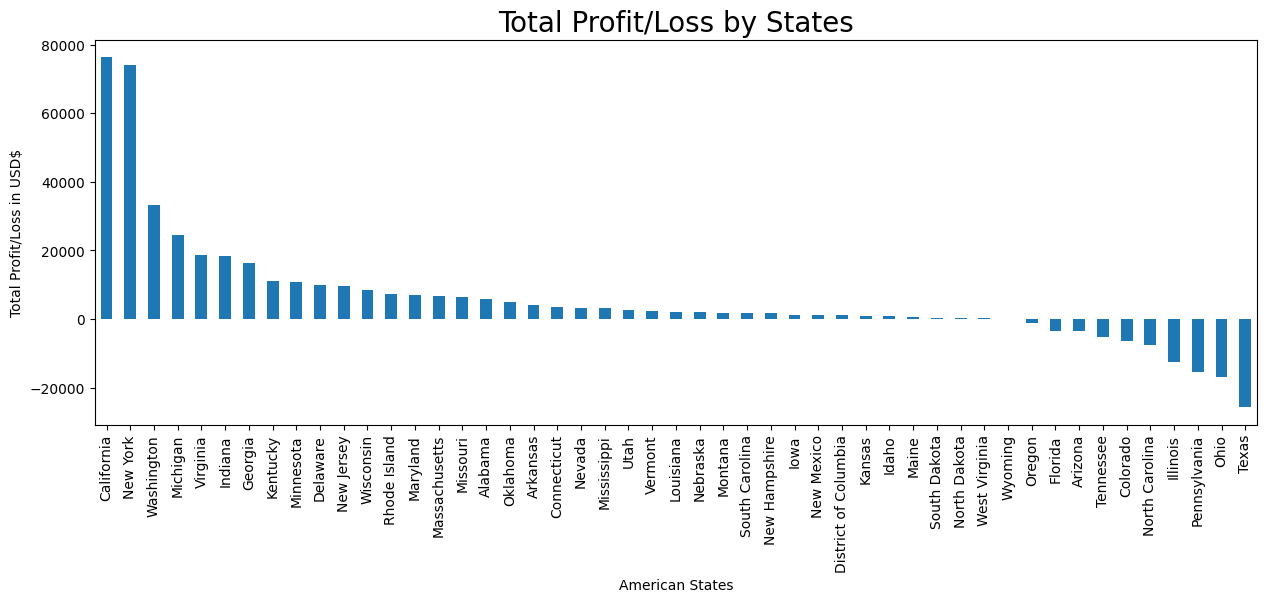

In [140]:
# Total Profit/Loss by States
df_state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending = False).plot.bar(figsize = (15, 5))
plt.ylabel('Total Profit/Loss in USD$')
plt.xlabel('American States')
plt.title('Total Profit/Loss by States', fontsize = 20)
plt.show()

## Business Q4: Which customer segments contribute most to sales and profit?

In [68]:
# Customer Segmentation (sum)
df.groupby("Segment")[["Sales", "Profit", "Quantity"]].sum()                   #Consumers generated most sales and profit 

,Sales,Profit,Quantity
Segment,,,
Consumer,1.161401e+06,134119.2092,19521
Corporate,7.061464e+05,91979.1340,11608
Home Office,4.296531e+05,60298.6785,6744


In [70]:
# Customer Segmentation (mean)
df.groupby("Segment")[["Sales", "Profit", "Discount", "Quantity"]].mean()

,Sales,Profit,Discount,Quantity
Segment,,,,
Consumer,223.733644,25.836873,0.158141,3.760547
Corporate,233.823300,30.456667,0.158228,3.843709
Home Office,240.972041,33.818664,0.147128,3.782389


<Axes: title={'center': 'Average Sales by Segment'}, xlabel='Segment'>

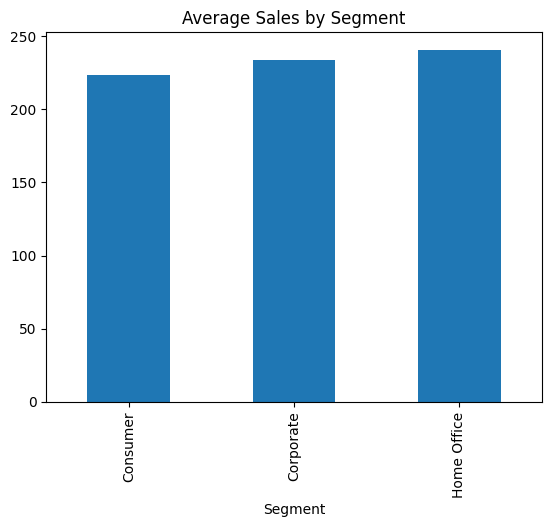

In [148]:
# Histogram for total sales by Segment
df.groupby("Segment")["Sales"].mean().plot(kind="bar", title="Average Sales by Segment")

<Axes: title={'center': 'Average Sales by Segment'}, xlabel='Segment'>

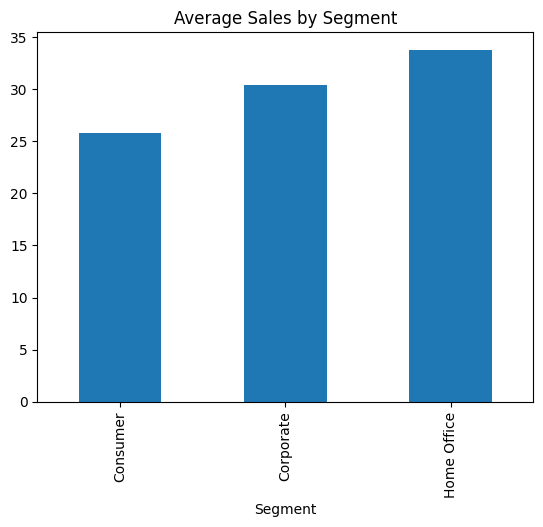

In [149]:
df.groupby("Segment")["Profit"].mean().plot(kind="bar", title="Average Sales by Segment")

In [77]:
# Combine Segment and Category
df.groupby(["Segment", "Category"])[["Sales", "Profit"]].sum()

Sales      Profit
Segment     Category                                
Consumer    Furniture        391049.3120   6991.0786
            Office Supplies  363952.1360  56330.3210
            Technology       406399.8970  70797.8096
Corporate   Furniture        229019.7858   7584.8158
            Office Supplies  230676.4620  40227.3202
            Technology       246450.1190  44166.9980
Home Office Furniture        121930.6975   3875.3784
            Office Supplies  124418.4340  25933.1596
            Technology       183304.0170  30490.1405

## Business Q5: How does shipping mode relate to performance?

In [110]:
# Count by each Ship Mode
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [152]:
# Sales by Shipping Mode 
df.groupby("Ship Mode")[["Sales", "Quantity", "Profit"]].mean()                  

,Sales,Quantity,Profit
Ship Mode,,,
First Class,228.497024,3.701560,31.839948
Same Day,236.396179,3.609576,29.266591
Second Class,236.089239,3.816452,29.535545
Standard Class,227.583067,3.819873,27.494770


<Axes: title={'center': 'Average Sales by Ship Mode'}, xlabel='Ship Mode'>

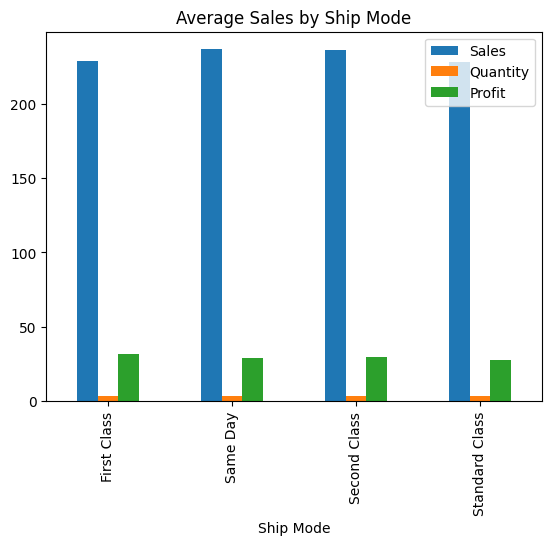

In [151]:
df.groupby("Ship Mode")[["Sales", "Quantity", "Profit"]].mean().plot(kind="bar", title="Average Sales by Ship Mode")

In [154]:
# Profit per unit of Ship Mode
df["Profit_per_unit"] = df["Profit"] / df["Quantity"]

df.groupby("Ship Mode")["Profit_per_unit"].mean()                          #Profit is actually highest for First Class when normalized by Quantity

Ship Mode
First Class       8.866269
Same Day          7.953386
Second Class      8.146918
Standard Class    7.397144
Name: Profit_per_unit, dtype: float64

In [111]:
# Normalize by Totals
ship_sales = df.groupby("Ship Mode")["Sales"].sum()
ship_sales / ship_sales.sum()                                             #Standard Class generates highest sales

Ship Mode
First Class       0.152981
Same Day          0.055878
Second Class      0.199893
Standard Class    0.591248
Name: Sales, dtype: float64

## Key Findings

- Technology is the highest-performing category in both revenue and profitability
- Discount strategy is the primary driver of profitability, with aggressive discounting leading to consistent margin erosion 
- Furniture underperforms despite similar discount levels, generating the lowest profit per order
- Consumer segment drives the majority of overall sales and profit
- Standard shipping dominates volume, while First Class shipping yields higher profit per unit

## Insight: Discount vs Profit

There is a clear negative relationship between discount levels and profitability:

- Low discounts (0–10%) maintain positive profit
- Profit declines sharply beyond ~20%
- High discounts (40%+) consistently result in losses

## Insight: Category-Level Performance

Discount levels are relatively similar across categories, yet profitability differs significantly:

- Furniture has the highest discount (~17%) and lowest average profit
- Technology has the lowest discount (~13%) and highest profitability

This indicates that discounting is not effectively aligned with profitability across categories.

## Business Implication

The findings suggest that current discount strategies are inefficient and may be eroding margins, particularly in the Furniture category.

In contrast, Technology products maintain strong profitability with lower discounting, indicating more effective pricing and stronger demand.

## Conclusion

Profitability is primarily driven by discount strategy and product mix rather than revenue alone.

Optimizing discount levels and focusing on high-performing categories can significantly improve overall business performance.

These findings highlight clear opportunities to improve profitability through more controlled discounting and targeted focus on high-performing product segments.